## DeepIsoQ: Predicting Isoform Expression From Gene-level Profiles Using Representation Learning

> **Context:** Be sure to check the `README`, in this folder, for a proper overview before diving in.

This notebook provides a structured overview of the DeepIsoQ repository and the components that make up the project. We briefly describe the purpose of each folder and script to help others quickly understand the workflow behind the models and analyses.

This serves as a documentation archive for the scripts in this folder. It is intended for reading, **not execution**.
(For that, we recommend using the Python scripts and the job scripts). 

In [7]:
import os, json, math, random, csv, time, pathlib, ast
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split

Data Preprocessing

## Feed-Forward Neural Network (FFNN)

This section explains the code for training a feed-forward neural network with different hyperparameters included in the script _ffnn_search_v2.py_. 

It is divided in 2 stages:

**Stage 1**:
- Random search over hyperparameters:
    * Number of hidden layers: 1–3 
    * Widths: {256, 512, 1024, 2048}
    * Activation: {tanh, ReLU, GELU, LeakyReLU}
    * Dropout: {0.0, 0.1, 0.2}
    * BatchNorm: {True, False}
    * BatchSize: {128, 192, 256}
    * Learning Rate: {$10^{-3}, 2·10^{-3}, 3·10^{-3}$}
- Max 50 epochs, early stopping + global pruning from epoch >= 30
- 100 trials (different configurations of hyperparameters)
- Saves: arch_search_results_stage1.csv, arch_search_summary_stage1.json, best_model_stage1.pt

**Stage 2**:
- Loads top-K configs from Stage-1 CSV (by val_mse)
- Retrains each for up to 200 epochs with early stopping (no global pruning)
- K = 5
- Saves: arch_search_results_stage2.csv, arch_search_summary_stage2.json, best_model_stage2.pt

**Both stages**:
- Use log1p(Y_tx) as targets, standardized Xg_log1p as inputs
- Compute test MSE + Pearson for best-by-val model in that stage

Now, we set a global configuration. Here, we include a seed, important to ensure the reproducibility of the code, irrespective of who runs it or when. It also allows for a fair comparison between architectures, as we ensure that the weights are initialized the same way. We want to run the model and all the tensors in an NVIDIA CUDA-enabled GPU if available, which is essential to accelerate the analyses.

In [8]:
SEED      = 42
TEST_FRAC = 0.15
VAL_FRAC  = 0.15
DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"
AMP       = (DEVICE == "cuda")

This code is run in two stages. In stage 1, we train 100 neural networks with different combinations of hyperparameters for 50 epochs. The five top-best performing configurations, i.e., the ones with the lowest validation error (TOP_K_STAGE2) are selected for the second stage, where they are fine-tuned for 200 epochs.

We set a value for gradient clipping (maximum L2 norm) to keep training stability by avoiding exploding gradients. The model performance will be computed and logged every 5 epochs, which we found to be a compromise between keeping track of the performance often enough without slowing down too much the training. 

In [9]:
STAGE        = 2          # set to 1 or 2
TOP_K_STAGE2 = 5          # number of best configs from Stage 1 to retrain in Stage 2

GRAD_CLIP    = 1.0
EVAL_EVERY   = 5          # evaluate every N epochs (both stages)

In the following cell, you can see how all hyperparameters are defined and the configuration of the two different stages of execution for this script.

In [10]:
# HPO search ranges (Stage 1)
BATCHES    = [128, 192, 256]
LRS        = [1e-3, 2e-3, 3e-3]
DROPOUTS   = [0.0, 0.1, 0.2]
BATCHNORMS = [False, True]
ACTS       = ["tanh", "relu", "gelu", "leakyrelu"]

# Architecture space: up to 3 layers, widths in this set
DEPTH_CHOICES = [1, 2, 3]
WIDTH_CHOICES = [256, 512, 1024, 2048]

# Stage-specific config
if STAGE == 1:
    N_TRIALS        = 100
    MAX_EPOCHS      = 50
    PATIENCE        = 5
    MIN_PRUNE_EPOCH = 30   # don't prune before this epoch
    PRUNE_FACTOR    = 1.5  # prune if val is > 1.5x global best
elif STAGE == 2:
    # N_TRIALS will be set after loading top-K from Stage-1 CSV
    N_TRIALS        = TOP_K_STAGE2
    MAX_EPOCHS      = 200
    PATIENCE        = 10
    MIN_PRUNE_EPOCH = None
    PRUNE_FACTOR    = None
else:
    raise ValueError("STAGE must be 1 or 2")

The running of both stages yielded a top 5 best performing models in terms of MSE and Pearson correlation. In the following cells, those results are imported from a CSV to generate some plots to visualize these two parameters in the top 5 models. 

In [11]:
#Set the theme for seaborn
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 25,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "figure.dpi": 300
})

In [12]:
# Path to the architecture search results CSV file
results_path = "~/DeepIsoQ/ffnn_search/results/arch_search_results_stage2.csv"
# Load the results into a DataFrame
results_df = pd.read_csv(results_path)
print("Loaded architecture search results:")
print(results_df.head())

Loaded architecture search results:
                 name  hidden        act  dropout  batchnorm     lr momentum  \
0   L1_512_t53_stage2   [512]       tanh      0.0       True  0.003        -   
1  L1_1024_t25_stage2  [1024]  leakyrelu      0.0       True  0.003        -   
2  L1_1024_t41_stage2  [1024]  leakyrelu      0.1       True  0.001        -   
3   L1_1024_t5_stage2  [1024]  leakyrelu      0.1       True  0.002        -   
4  L1_1024_t56_stage2  [1024]       gelu      0.2       True  0.001        -   

  step_size gamma  batch_size  epochs_trained   val_mse  val_pearson  \
0         -     -         128             200  0.843434     0.744078   
1         -     -         256             200  0.843881     0.744401   
2         -     -         128             200  0.859592     0.741751   
3         -     -         192             200  0.857438     0.742168   
4         -     -         128             200  0.841696     0.746201   

   train_time_sec  
0           243.9  
1         

In [13]:
#Sort by validation MSE
df_mse = results_df.sort_values("val_mse", ascending = True)

#Sort by validation Pearson correlation
df_pearson = results_df.sort_values("val_pearson", ascending = False)


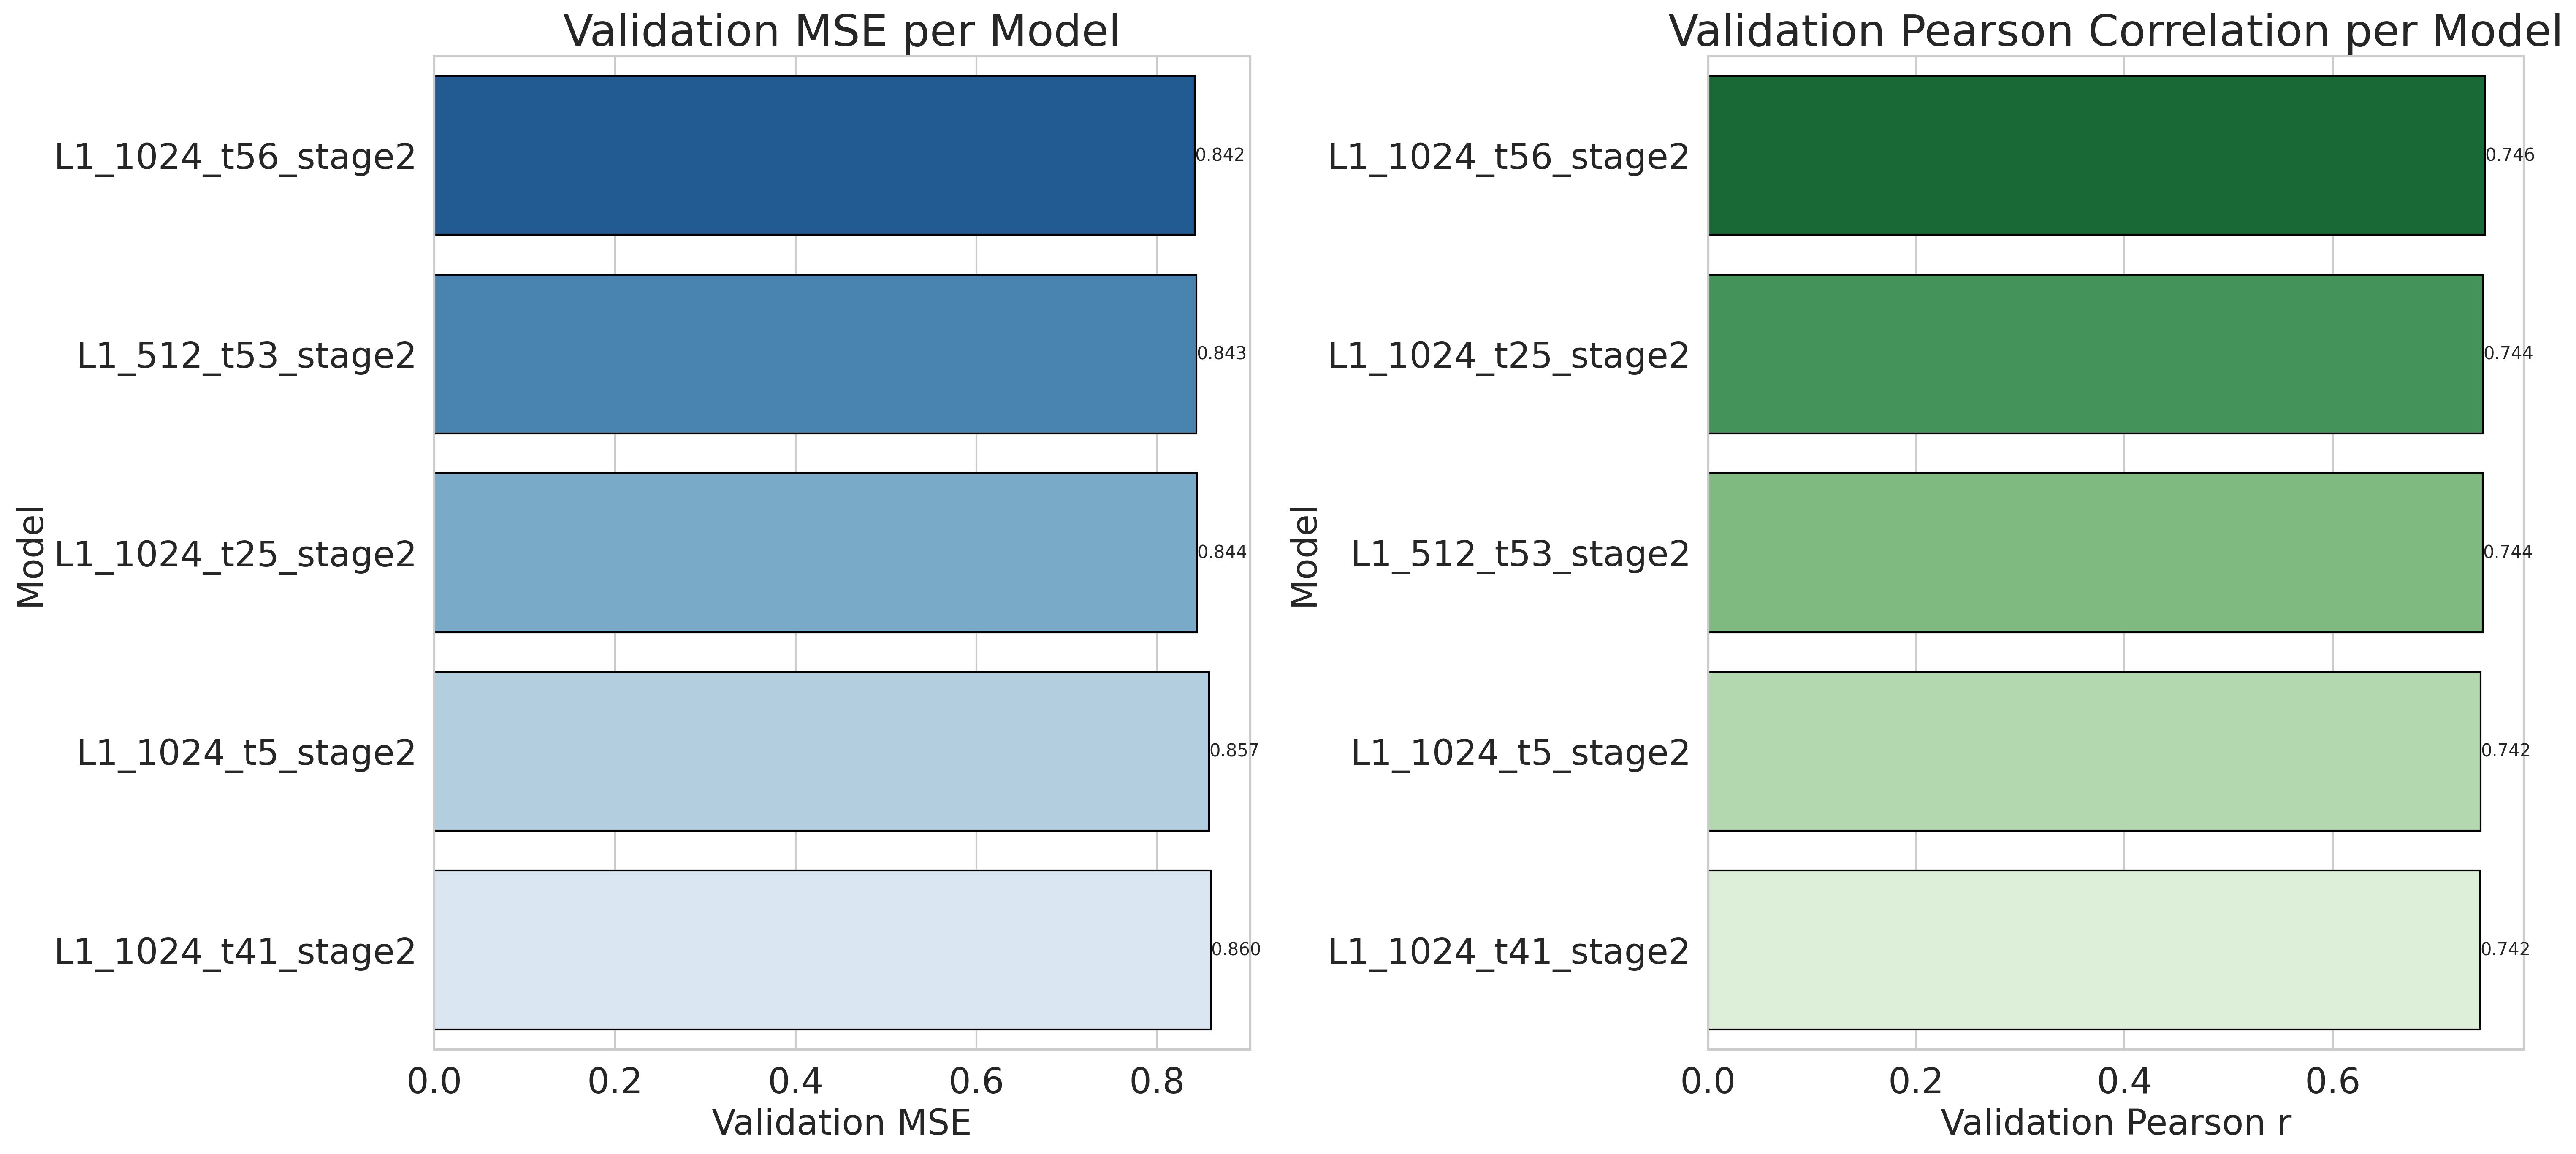

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9), constrained_layout=True)

# Validation MSE
sns.barplot(
    ax=axes[0],
    data=df_mse,
    y="name",
    x="val_mse",
    hue="name",
    palette="Blues_r",
    edgecolor="black",
    legend=False
)
axes[0].set_title("Validation MSE per Model")
axes[0].set_xlabel("Validation MSE")
axes[0].set_ylabel("Model")
# Annotate bars with MSE values
for i, v in enumerate(df_mse["val_mse"]):
    axes[0].text(v, i, f"{v:.3f}", va="center", ha="left", fontsize=10)

# Validation Pearson Correlation
sns.barplot(
    ax=axes[1],
    data=df_pearson,
    y="name",
    x="val_pearson",
    hue="name",
    palette="Greens_r",
    edgecolor="black",
    legend=False
)
axes[1].set_title("Validation Pearson Correlation per Model")
axes[1].set_xlabel("Validation Pearson r")
axes[1].set_ylabel("Model")
# Annotate bars with Pearson r values
for i, v in enumerate(df_pearson["val_pearson"]):
    axes[1].text(v, i, f"{v:.3f}", va="center", ha="left", fontsize=10)

plt.show()

### Adding Residual Connections to the MLP Architecture

The script _ffnn_search_resnet.py_ builds on the previous one by extending the feed-forward architecture to support residual connections. The goal is to allow experimentation with a residual variant within the same training framework.

To new components where introduce: 
- **ResidualBlock**: A building block that applies: two linear transformations, optional batch normalization,a non-linear activation, optional dropout, and a residual shortcut.

- **ResidualFFNN**: A residual version of the multilayer perceptron.
Instead of stacking simple linear layers, it stacks multiple **ResidualBlocks**, one for each hidden dimension specified in the architecture.

In [17]:
# Path to the architecture search results CSV file
results_path = "~/DeepIsoQ/ffnn_search/results/residuals_arch_search_results_stage2.csv"

# Load the results into a DataFrame
results_df = pd.read_csv(results_path)
print("Loaded architecture search results:")
print(results_df.head())

Loaded architecture search results:
                         name             hidden        act  dropout  \
0  L3_256_2048_2048_t3_stage2  [256, 2048, 2048]  leakyrelu      0.0   
1            L1_512_t0_stage2              [512]       gelu      0.0   
2           L1_256_t10_stage2              [256]       gelu      0.0   

   batchnorm     lr momentum step_size gamma  batch_size  epochs_trained  \
0       True  0.001        -         -     -         192             100   
1       True  0.002        -         -     -         192             135   
2       True  0.002        -         -     -         128             125   

    val_mse  val_pearson  train_time_sec  residual  
0  0.926542     0.716932           514.4      True  
1  0.949994     0.710659           264.5      True  
2  0.981363     0.698767           190.4      True  


In [18]:
# Sort by validation MSE
df_mse = results_df.sort_values("val_mse", ascending=True)

# Sort by validation Pearson correlation
df_pearson = results_df.sort_values("val_pearson", ascending=False)

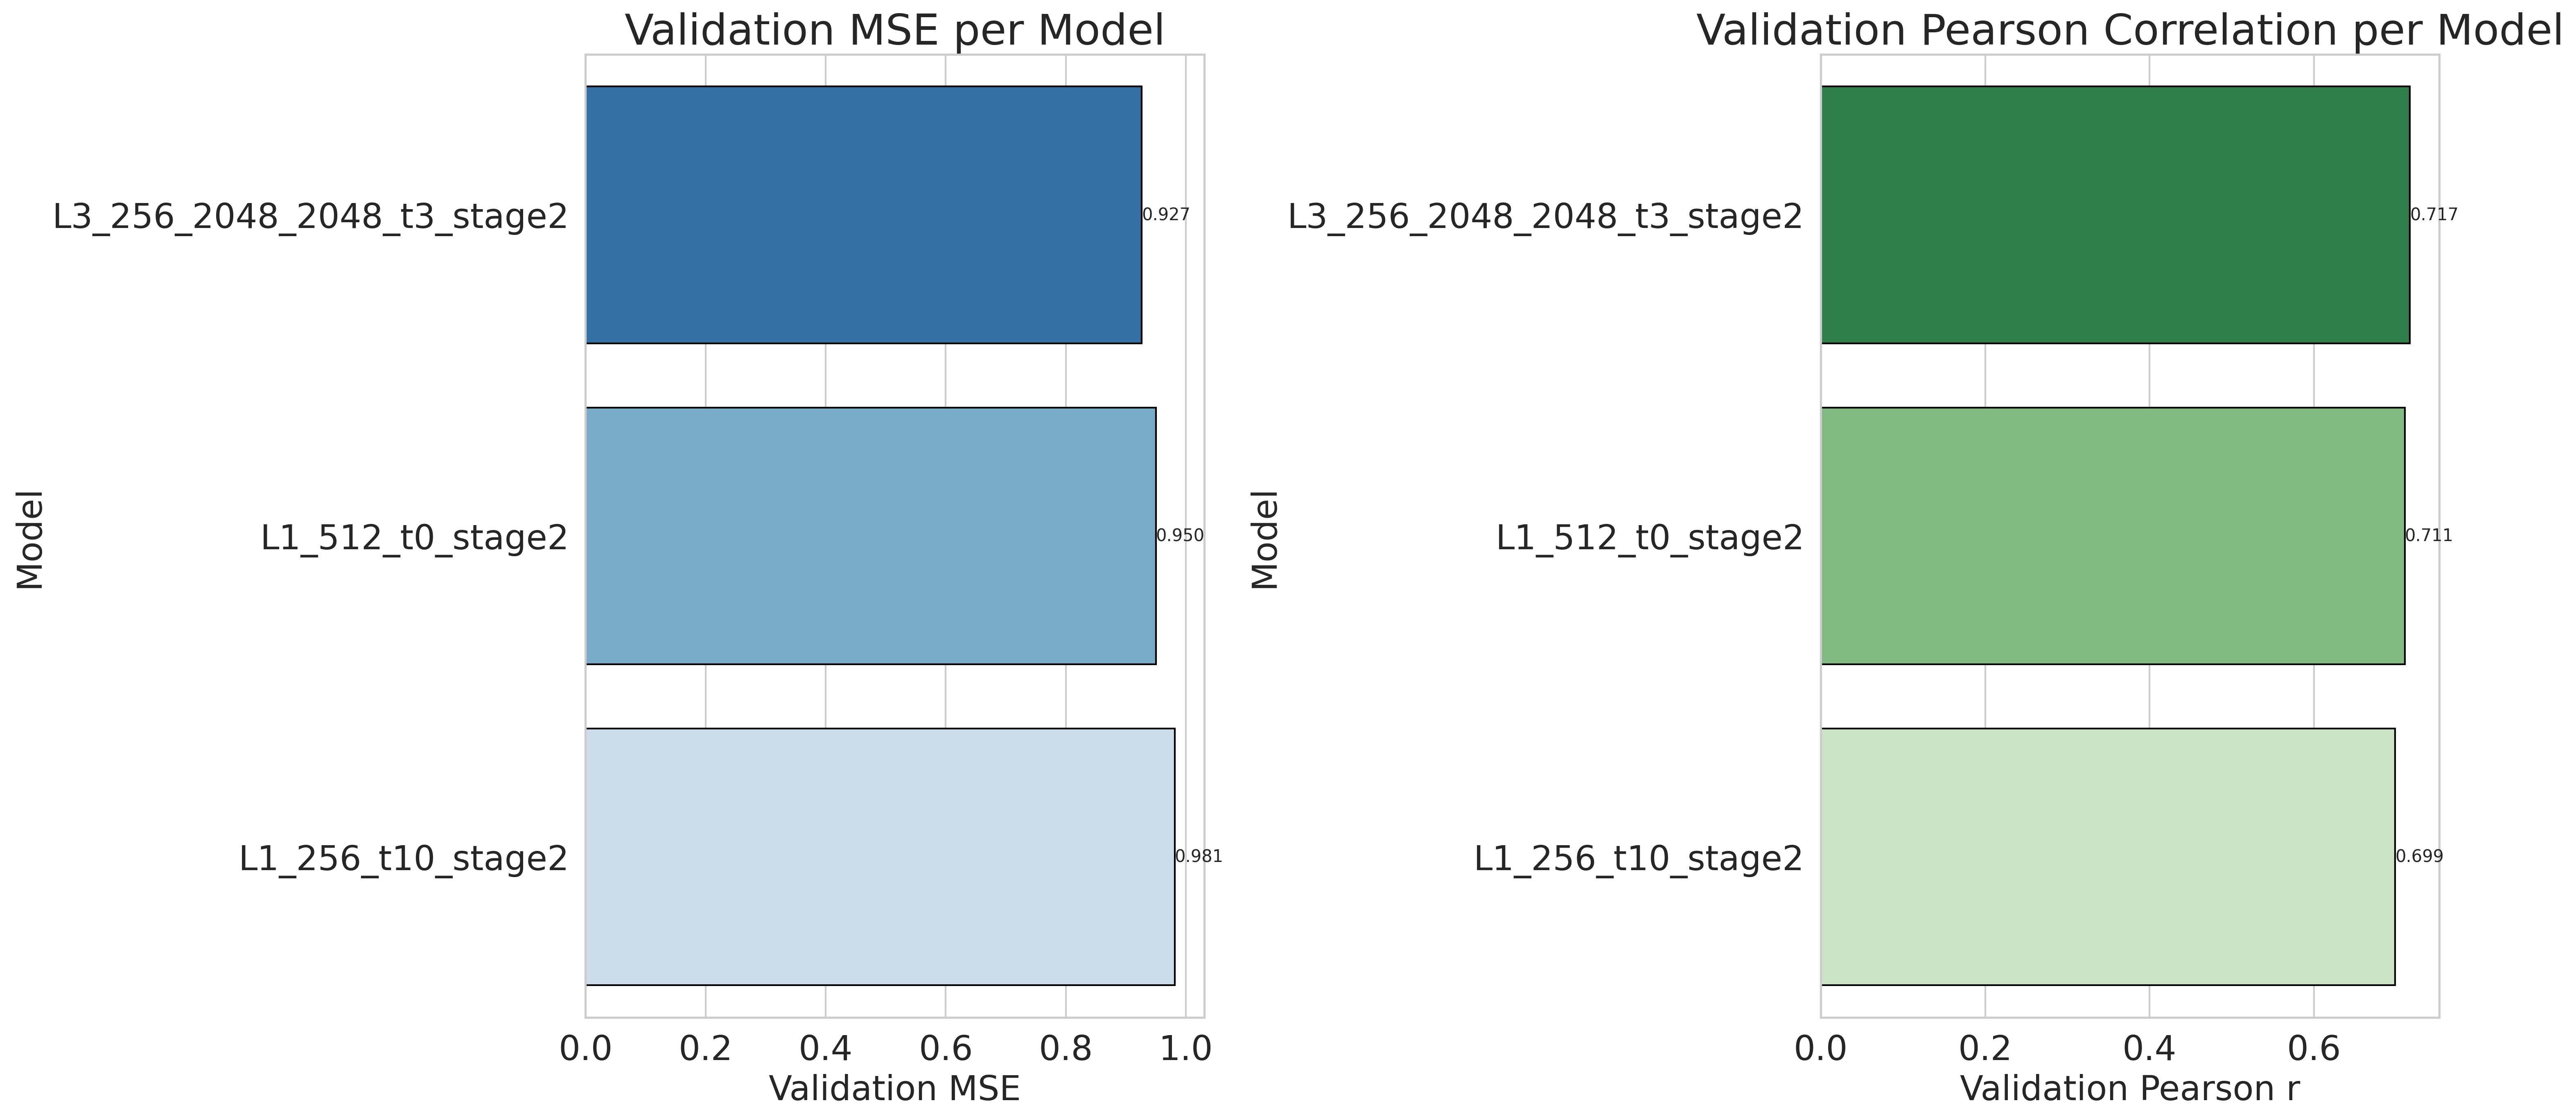

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9), constrained_layout=True)

# Validation MSE
sns.barplot(
    ax=axes[0],
    data=df_mse,
    y="name",
    x="val_mse",
    hue="name",
    palette="Blues_r",
    edgecolor="black",
    legend=False
)
axes[0].set_title("Validation MSE per Model")
axes[0].set_xlabel("Validation MSE")
axes[0].set_ylabel("Model")

# Annotate bars with MSE values
for i, v in enumerate(df_mse["val_mse"]):
    axes[0].text(v, i, f"{v:.3f}", va="center", ha="left", fontsize=10)

# Validation Pearson Correlation
sns.barplot(
    ax=axes[1],
    data=df_pearson,
    y="name",
    x="val_pearson",
    hue="name",
    palette="Greens_r",
    edgecolor="black",
    legend=False
)
axes[1].set_title("Validation Pearson Correlation per Model")
axes[1].set_xlabel("Validation Pearson r")
axes[1].set_ylabel("Model")

# Annotate bars with Pearson r values
for i, v in enumerate(df_pearson["val_pearson"]):
    axes[1].text(v, i, f"{v:.3f}", va="center", ha="left", fontsize=10)

plt.show()

## Principal Component Analysis (PCA)

#### Data Preprocessing:
This model handles data scaling differently than the others:
1.  **Scaling:** Both Gene (X) and Transcript (Y) data are normalized using `StandardScaler`.
2.  **Evaluation:** To maintain consistency with other models (which only scale X), we apply an **inverse transform** to the outputs before calculating the MSE. This ensures all performance metrics are reported in the same unit space.

#### The Code:

- **`pca_script.py`:** The first PCA-based FFNN script that was created. Its main purpose was that of an mostly exploratory script. 

- **`pca_dim_search.py`:** The script which explores multiple (user-defined) different PCA dimensions in order determine the one which leads to best performance. <br>
<br>
Admittedly, the algorithm would arguably be more proper in exploring PCA dimensions, if it hadn't kept the hyperparameters fixed. <br>
Although that would also have severely increase the computational resource and time demand. <br>
\- which we decided wasn't a justifiable use of the HPC cluster's resources. <br>
<br>
Therefore we went for another more resource friendly approach. 

- **`multiple_pca_script.py`:** This script was adapted from `ffnn_search/ffnn_search.py`. <br>
Its purpose is to determine the best configuration of hyperparameters for the PCA-based FFNN model. <br>
It uses a heuristic approach to pick hyperparameters to chose from. <br>
<br>
Just like `ffnn_search/ffnn_search.py`, this code has Stage 1 and a Stage 2 functionality, which the user manually needs to switch on. <br>
The stage 2 was never tried out, as this feature seemed more relevant for the raw data FFNN than the PCA-based FFNN. <br>

- **`pca_best_model.py`:** This script trains and tests the best model from the `multiple_pca_script.py` script. <br>
Additionally, this script also calculates and outputs some extra metrics for the report - such as MSE for both test AND validation. 

### **The code of `pca_script.py`:**

In [ ]:
# ------------------------------
# Save Results & Plots
# ------------------------------

# 1. Save Training Curve Plot
try:
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss (Scaled)', marker='o')
    plt.plot(val_losses, label='Validation Loss (Scaled)', marker='s')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss (Scaled)')
    plt.title(f'PCA FFNN (PCA={PCA_DIM}) | Job: {JOB_ID}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(FIG_PATH, dpi=150)
    plt.close()
    print(f"[INFO] Plot saved to: {FIG_PATH}")
except Exception as e:
    print(f"[WARN] Failed to save plot: {e}")

# 2. Save Metrics to JSON
summary = {
    "meta": {
        "job_id": JOB_ID,
        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S")
    },
    "config": {
        "pca_dim": PCA_DIM,
        "batch_size": BATCH_SIZE,
        "lr": LR,
        "epochs": N_EPOCHS,
        "seed": SEED
    },
    "results": {
        "final_train_mse_scaled": train_losses[-1],
        "final_val_mse_scaled": val_losses[-1],
        "test_mse_scaled": float(((P_scaled - T_scaled)**2).mean()),
        "test_mse_unscaled": float(final_test_mse_unscaled), # This is the key metric for comparing our models. The scaled MSE is less relevant. 
        "total_time_sec": round(total_time, 2)
    }
}
with open(JSON_PATH, "w") as f:
    json.dump(summary, f, indent=4)
print(f"[INFO] Metrics saved to: {JSON_PATH}")

# 3. Save Logs to CSV
with open(CSV_PATH, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["epoch", "train_mse_scaled", "val_mse_scaled"])
    for i in range(N_EPOCHS):
        writer.writerow([i+1, train_losses[i], val_losses[i]])

print("[INFO] All done.")

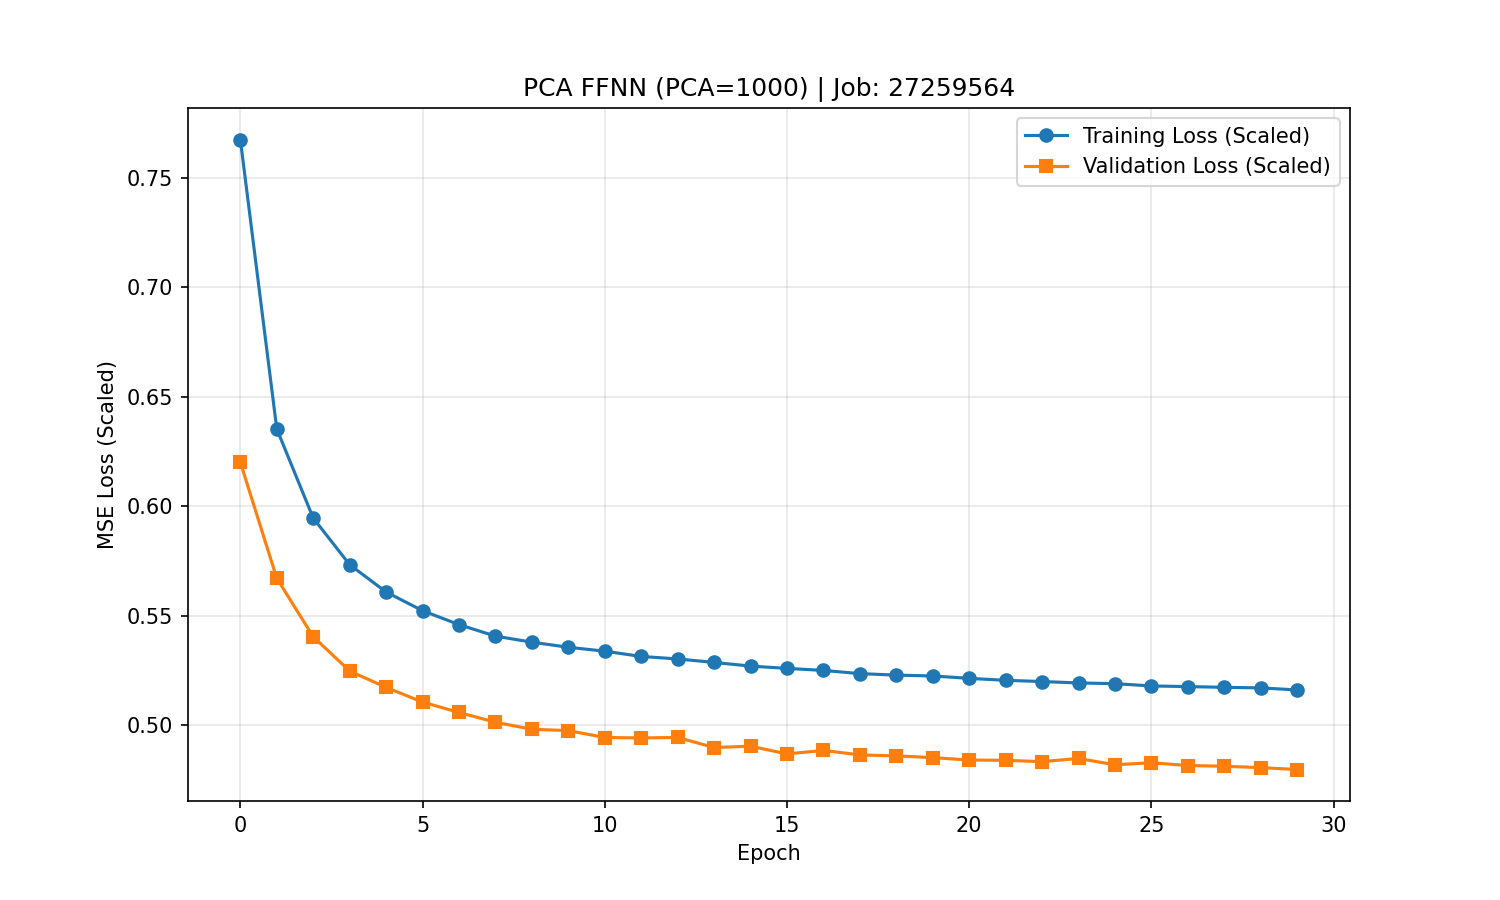

### **The code of `pca_dim_search.py`:**

In [ ]:

# ------------------------------
# Main Sweep Loop - test out the PCA dimensions that were inputted in the config section
# ------------------------------
results = []

# CSV Init
with open(RESULTS_CSV, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["pca_dim", "test_mse_unscaled", "test_mse_scaled", "time_sec"])
    w.writeheader()

print("\n=== STARTING PCA SWEEP ===")
for dim in PCA_DIMS_TO_TEST:
    res = train_and_evaluate(dim)
    results.append(res)
    
    # Update CSV
    with open(RESULTS_CSV, "a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=res.keys())
        w.writerow(res)
    
    print(f"[RESULT] Dim {dim} -> Test MSE (Unscaled): {res['test_mse_unscaled']:.4f}")
 
# ------------------------------
# Summary Plot
# ------------------------------
dims = [r["pca_dim"] for r in results]
mses = [r["test_mse_unscaled"] for r in results]

plt.figure(figsize=(8, 5))
plt.plot(dims, mses, marker='o', linestyle='-', linewidth=2, color='b')
plt.xlabel("Number of PCA Components")
plt.ylabel("Test MSE (Unscaled)")
plt.title("Model Performance vs. PCA Dimension")
plt.grid(True, alpha=0.3)
plt.savefig(SWEEP_PLOT, dpi=150)
plt.close()

# Save JSON
with open(SUMMARY_JSON, "w") as f:
    json.dump({"fixed_hp": FIXED_HP, "results": results}, f, indent=4)

print(f"\n[INFO] Sweep Complete. Summary plot saved to {SWEEP_PLOT}")


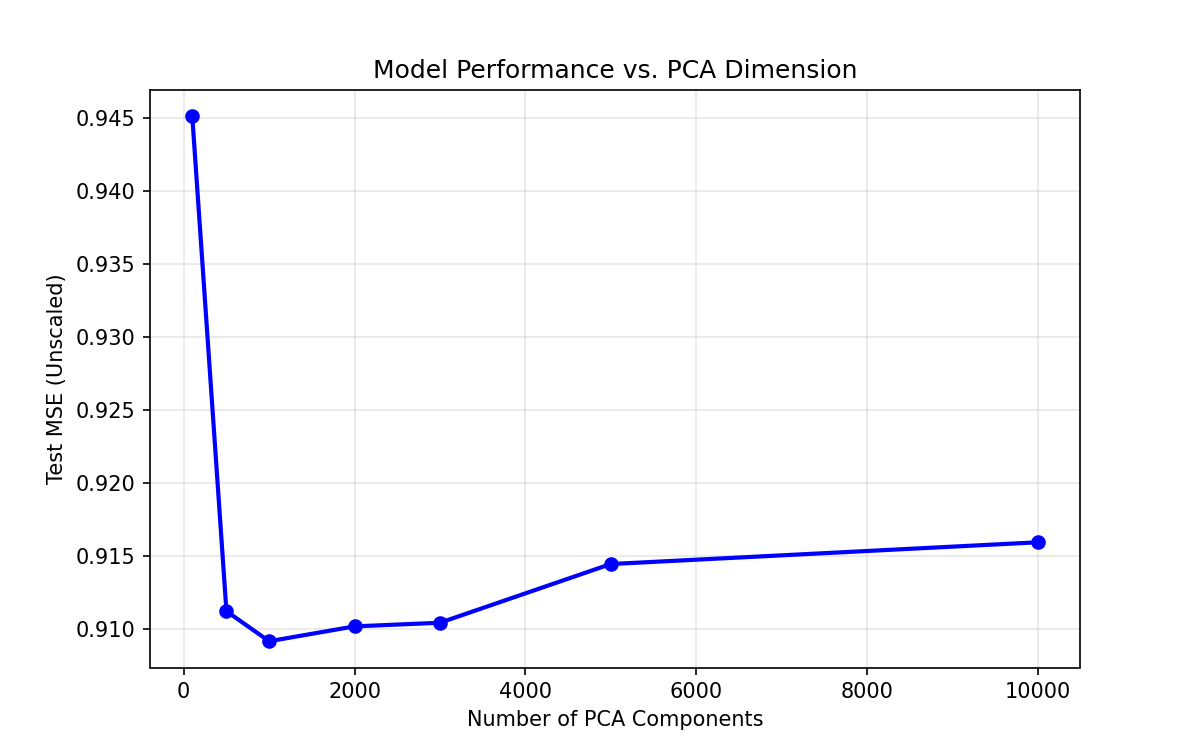

### **The code of `multiple_pca_script.py`:**

In [ ]:
# ------------------------------
# Final Evaluation (Unscaling)
# ------------------------------
print("\n[INFO] Evaluating Best Model on Test Set (UNSCALED)...")
model = FFNN(PCA_DIM, Y.shape[1], best_rec["hidden"], best_rec["act"], best_rec["dropout"], best_rec["batchnorm"]).to(DEVICE)
model.load_state_dict(best_state_global)
model.eval()

te_loader = get_loader(test_ds, best_rec["batch_size"], False)
preds_list, targs_list = [], []

with torch.no_grad():
    for xb, yb in te_loader:
        xb = xb.to(DEVICE)
        p = model(xb)
        preds_list.append(p.cpu().numpy())
        targs_list.append(yb.numpy())

P_scaled = np.vstack(preds_list)
T_scaled = np.vstack(targs_list)

#Inverse scaling transformation back to the log1p space: 
P_log1p = scaler_y.inverse_transform(P_scaled)
T_log1p = scaler_y.inverse_transform(T_scaled)

final_mse = ((P_log1p - T_log1p)**2).mean()

#GPU-friendly Pearson correlation calculation:
yt = torch.tensor(T_log1p, device=DEVICE)
yp = torch.tensor(P_log1p, device=DEVICE)
yt = yt - yt.mean(0, keepdim=True)
yp = yp - yp.mean(0, keepdim=True)
num = (yt * yp).sum(0)
den = torch.sqrt((yt**2).sum(0)) * torch.sqrt((yp**2).sum(0)) + 1e-8
pearson = (num / den).mean().item()

print(f"\n[FINAL RESULTS] Job: {JOB_ID}")
print(f"Best Config: {best_rec['name']}")
print(f"Test MSE (Scaled):   {((P_scaled - T_scaled)**2).mean():.4f}")
print(f"Test MSE (Unscaled) - Comparable to normal FFNN Model: {final_mse:.4f}")
print(f"Test Pearson:        {pearson:.4f}")

# Save Summary
# [FIX] Cast numpy/torch floats to standard python floats for JSON serialization
summary = {
    "stage": STAGE,
    "job_id": JOB_ID,
    "best_config": best_rec,
    "metrics": {
        "test_mse_unscaled": float(final_mse), #The float() is important to prevent an error when writing the JSON file!
        "test_pearson": float(pearson)         #Same as above. 
    }
}
with open(SUMMARY_JSON, "w") as f:
    json.dump(summary, f, indent=4)

print("[INFO] Done.")

**Output:**
<br>
The stats of the top 5 models can be printed in the terminal, by using this bash command: 

`sort -t, -k9,9g PCA/results/pca_results_stage1_<INSERT THE JOB ID HERE>.csv | head -n 6`

The output will look like this:
```
name,hidden,act,dropout,batchnorm,lr,batch_size,epochs,val_mse,time
L1_512_t53,[512],tanh,0.0,True,0.003,128,50,0.43038272583920245,330.3
L1_1024_t56,[1024],gelu,0.2,True,0.001,128,50,0.4350384364801887,405.4
L1_512_t0,[512],gelu,0.0,True,0.002,192,50,0.43511436547443366,311.6
L1_512_t14,[512],gelu,0.0,True,0.002,256,50,0.43626452115730596,296.7
L1_1024_t25,[1024],leakyrelu,0.0,True,0.003,256,50,0.4401809416019473,334.8
```
| Model Name | Hidden Layers | Activation | Dropout | Batch Norm | Learning Rate | Batch Size | Epochs | Val MSE | Time (s) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **L1_512_t53** | 512 | Tanh | 0.0 | Yes | 0.003 | 128 | 50 | **0.4304** | 330.3 |
| L1_1024_t56 | 1024 | GELU | 0.2 | Yes | 0.001 | 128 | 50 | 0.4350 | 405.4 |
| L1_512_t0 | 512 | GELU | 0.0 | Yes | 0.002 | 192 | 50 | 0.4351 | 311.6 |
| L1_512_t14 | 512 | GELU | 0.0 | Yes | 0.002 | 256 | 50 | 0.4363 | 296.7 |
| L1_1024_t25 | 1024 | LeakyReLU | 0.0 | Yes | 0.003 | 256 | 50 | 0.4402 | 334.8 |


### **The code of `pca_best_model.py`:**

In [ ]:
# ------------------------------
# 6. Final Evaluation (Scaled MSE, Unscaled MSE, Pearson)
# ------------------------------
print("\n[INFO] Calculating Final Metrics for Table...")

model.eval()

def get_comprehensive_metrics(loader):
    preds_list, true_list = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            p = model(xb)
            preds_list.append(p.cpu().numpy())
            true_list.append(yb.numpy()) 
    
    #Stack: 
    P_scaled = np.vstack(preds_list)
    T_scaled = np.vstack(true_list)
    
    # 1. Scaled MSE
    mse_scaled = ((P_scaled - T_scaled)**2).mean()

    # 2. Unscaled MSE (inverse scaling transformation)
    P_log1p = scaler_y.inverse_transform(P_scaled)
    T_log1p = scaler_y.inverse_transform(T_scaled)
    mse_unscaled = ((P_log1p - T_log1p)**2).mean()
    
    # 3. Pearson correlation (on unscaled data): 
    P_t = torch.tensor(P_log1p, device=DEVICE)
    T_t = torch.tensor(T_log1p, device=DEVICE)
    rho = pearson_corr_gpu(P_t, T_t)
    
    return float(mse_scaled), float(mse_unscaled), float(rho)

val_sc, val_un, val_rho = get_comprehensive_metrics(val_loader)
test_sc, test_un, test_rho = get_comprehensive_metrics(test_loader)

print("="*60)
print("FINAL RESULTS FOR TABLE")
print("="*60)
print(f"VALIDATION:")
print(f"  MSE (Unscaled): {val_un:.4f}")
print(f"  Pearson (rho):  {val_rho:.4f}")
print("-" * 30)
print(f"TEST:")
print(f"  MSE (Unscaled): {test_un:.4f}")
print(f"  Pearson (rho):  {test_rho:.4f}")
print("="*60)


# ------------------------------
# 7. Plotting - Training curve: 
# ------------------------------
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(history["train_mse"])+1), history["train_mse"], label="Train MSE (Scaled)", marker='.')
plt.plot(range(1, len(history["val_mse"])+1), history["val_mse"], label="Val MSE (Scaled)", marker='.')
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (Scaled)")
plt.title(f"Training Curve (PCA={BEST_HP['pca_dim']})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(PLOT_PATH, dpi=300)
plt.close()

print(f"[SUCCESS] Done. Plot: {PLOT_PATH}")


#Save metrics: 
with open(JSON_PATH, "w") as f:
    json.dump({
        "hp": BEST_HP,
        "validation": {"mse_scaled": val_sc, "mse_unscaled": val_un, "rho": val_rho},
        "test":       {"mse_scaled": test_sc, "mse_unscaled": test_un, "rho": test_rho}
    }, f, indent=4)

print("[SUCCESS] Final metrics saved to:", JSON_PATH)


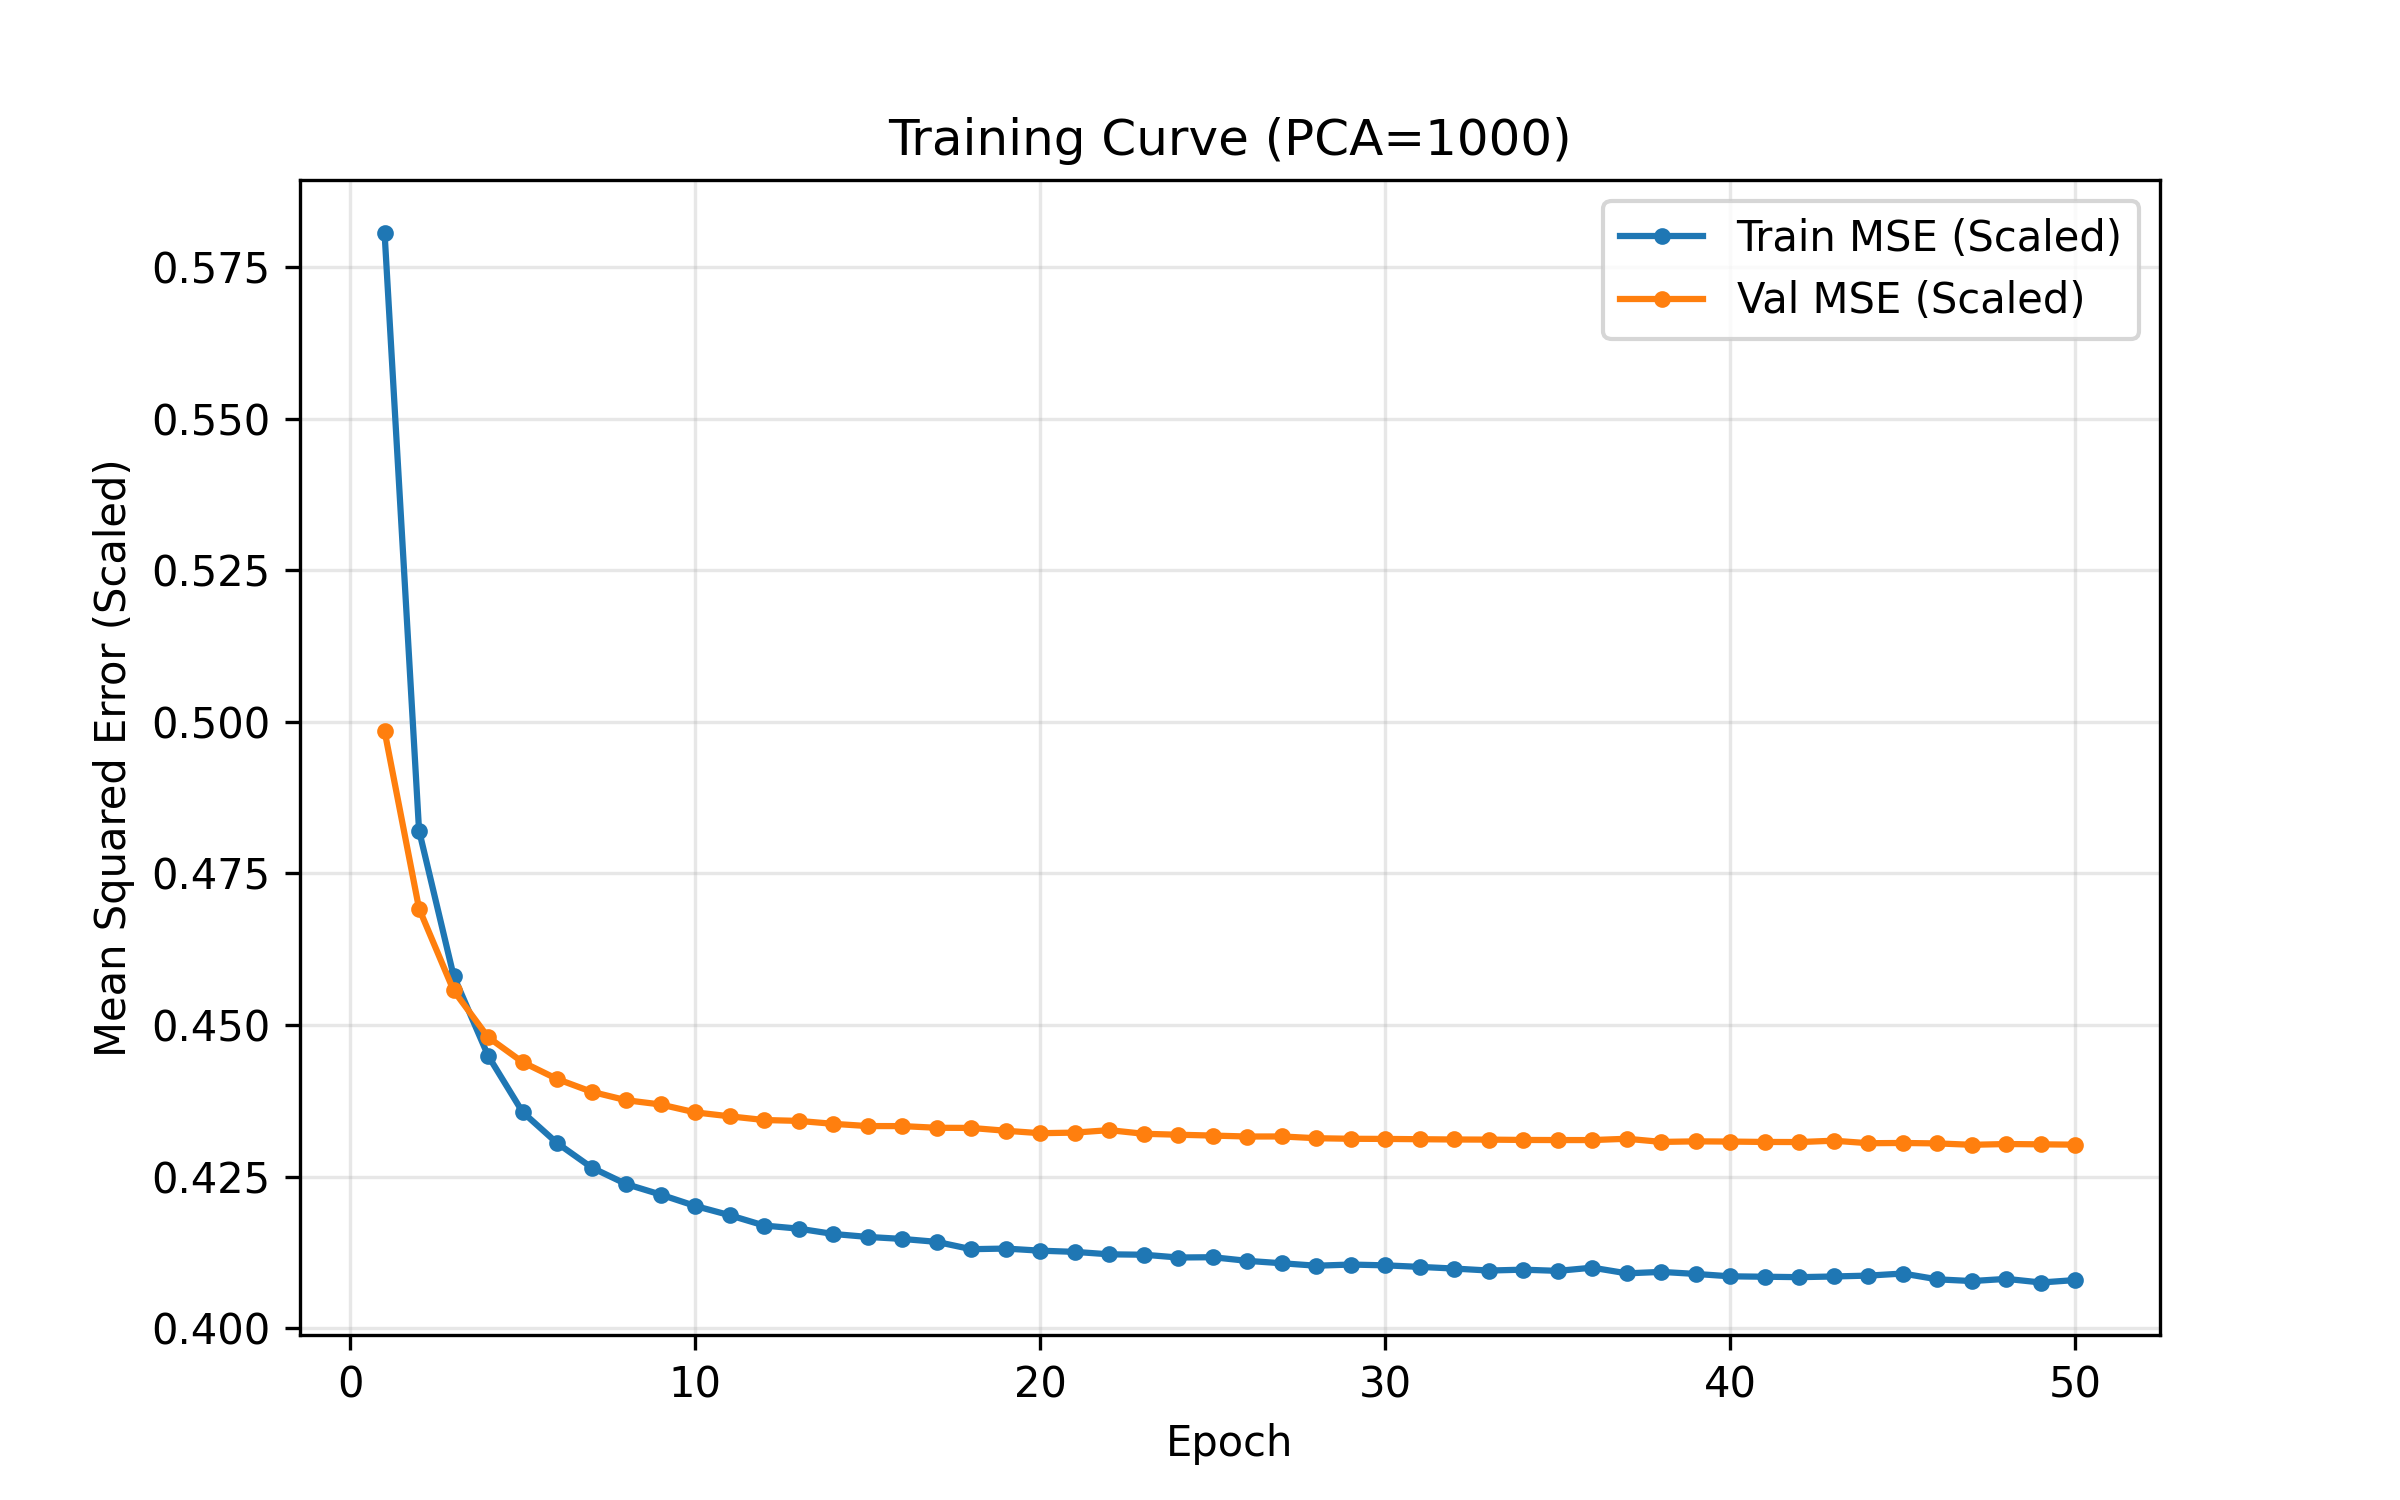

## Variational Autoencoders (VAE)

In `VAE` folder, the user can find the different scripts used to apply variational autoencoders for the generation of embedding from raw gene expression datasets. 

* **The script `variational_autoencoder_nb.py`** contains the code for the generation of the embeddings. 
    -   It implements the Gaussian distribution with the reparametrization trick (used for the prior and the approximate posterior distributions). 
    -   It implements the negative binomial for the likelihood function. 

    So, we end up with a prior defined as: $$p(\mathbf{z}) := \mathcal{N}(0, I)$$

    An approximate posterior:  $$q_\phi(\mathbf{z} | \mathbf{x}) := \mathcal{N}( \mathbf{z}\ |\ \mu_\phi(\mathbf{x}) , \sigma_\phi(\mathbf{x}) I )$$

    The datasets, as in the rest of the scripts of this repository, are hosted in the folder `$BLACKHOLE/$USER`. Here, we are only considering the 'x' (that is, the raw gene expression datas, excluding the transcript datasets). The reason for this is because VAE are an unsupervised deep learning method, a generative model. Therefore, it does not need labels. 

    Note that, in contrast with other scripts from this project, the data is not log-transform, because the observation model used (a negative binomial) is used to work directly with raw counts. 

    The dataset is then divided between train, test and validation sets following the same procedure as described in other sections (with the function train_test_split, in proportions 70%, 15% and 15%, respectively).

    -   The class `VariationalAutoencoder` includes functions that define the probability distributions and the main execution flows. Particularly, the function `posterior` implements the encoder and returns the distribution $q_\phi(\mathbf{z} | \mathbf{x})$. The function `prior` implements the prior distribution of the latent space. The function `observation_model` implements the decoder and returns the negative binomial distribution $p_\phi(\mathbf{x} | \mathbf{z})$. The function `forward` computes all the necessary components for the Evidence Lower Bound (ELBO) loss function, used in the training. Finally, the aim of the function `sample_from_prior` is to generate new data samples once the VAE has been trained. 

    -   The class `VariationalInference` computes the $\beta$-ELBO. Here, we have an important hyperparameter to tune, $\beta$. It acts as a regularization weight, controlling the trade-off between the two components of the loss function (the reconstruction term and the regularization). Higher values of $\beta$ force the model to find latent representations close to the Gaussian prior. Conversely, lower values allow the posterior to deviate more from the prior. In our notebook, we have included $\beta$-annealing, with 50 warm-up epochs and a $\beta$ target of 1.0. This increases its value progressively throught the training process. 

    -   Then, the notebook continues with the training and evaluation loops. The objective here is to optimize the VAE's parameters using the $\beta$-ELBO loss, and keeping track of the performance of both the training and validation. We clip the gradients to prevent exploding gradients, a problem we have faced in the different runs. The results of the training curves is visualised with the function `make_vae_plots`. 

    -   The function `get_vae_latents` returns the latent representations for all samples. These are later saved for using them in FFNN. 

* **The script `variational_autoencoders_hyperparams.py`** has the same elementary pieces as `variational_autoencoder_nb.py`, but here we tried to search for different hyperparameter options to try to improve the performance.  

* **The script `variational_autoencoder_isoform.py`** tries to apply a semi-supervised learning approach. The loss funcion does not only include the ELBO ('unsupervised error'), but also MSE ('supervised error on Y'). The total final loss was computed as the sum of the unsupervised learning and the supervised learning, with a regularisation parameter $\lambda$ multiplying this latter. However, this strategy didn't seem to work very well and, as a result, it can be outdated with respect to the previous two. 

As part of our main results, this plot illustrates how the size of the VAE latent representation affects the downstream FFNN performance, evaluated using MSE and Pearson correlation on validation and test sets.

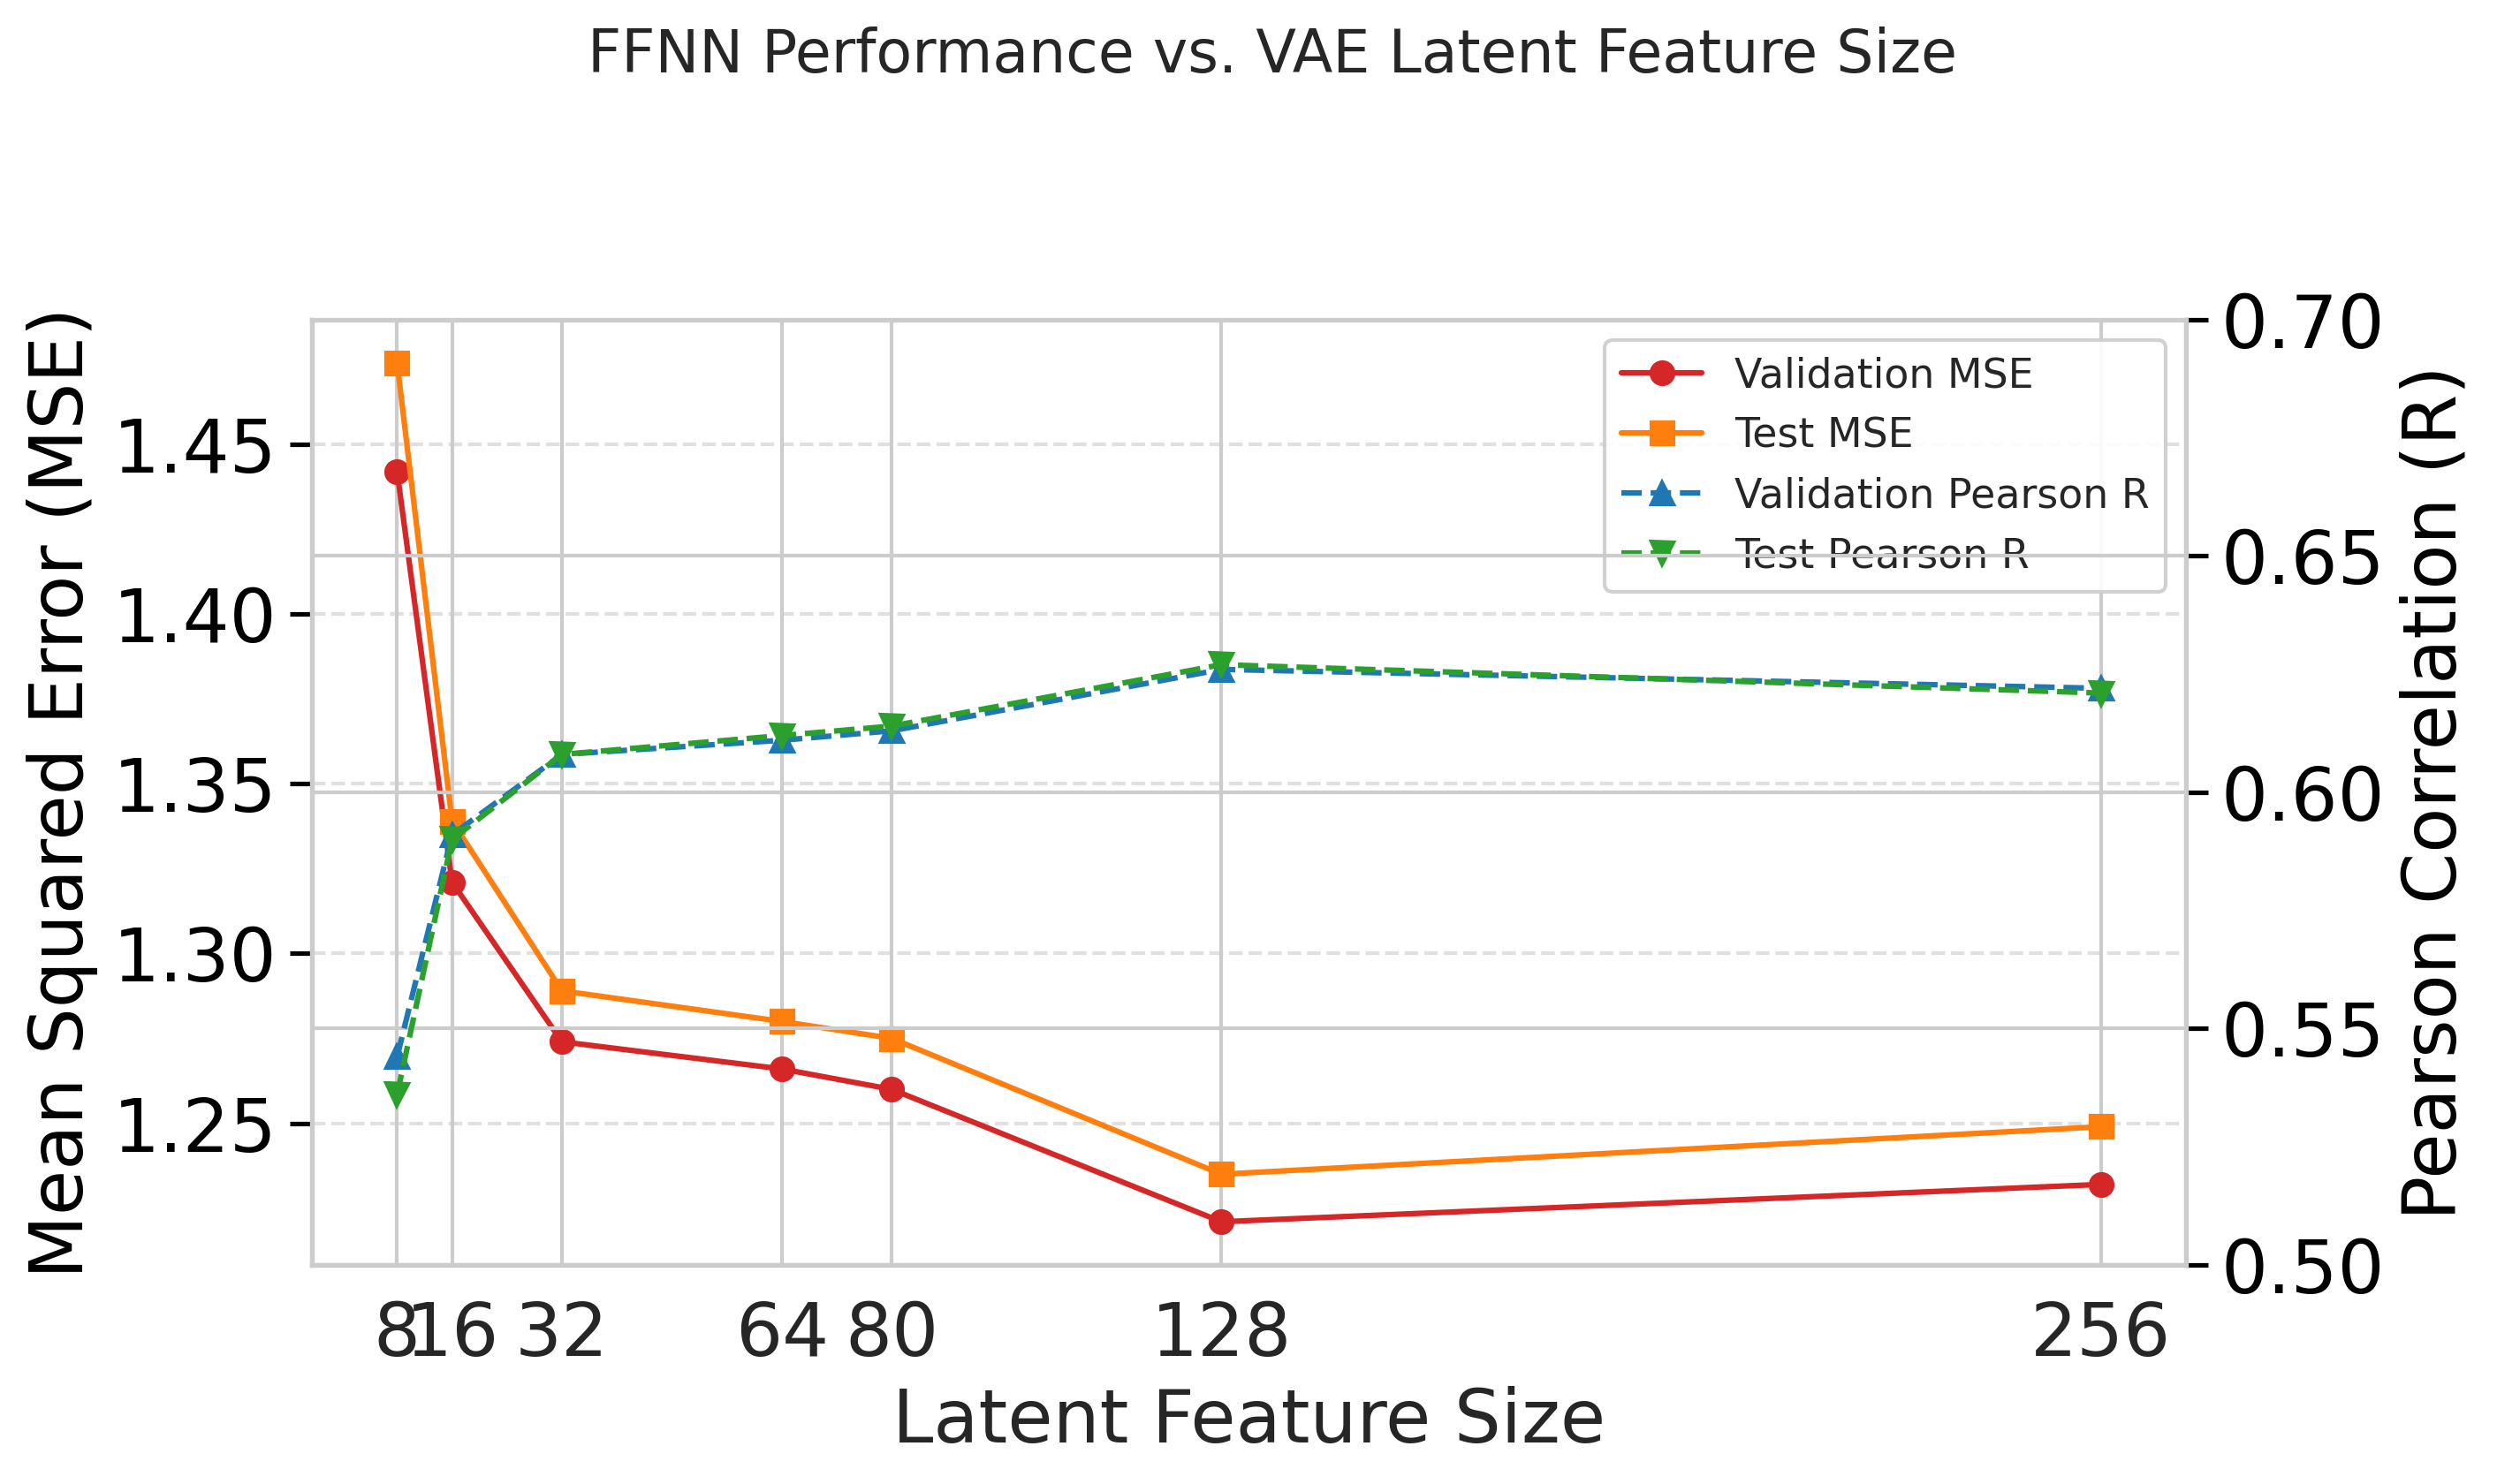

<Figure size 1920x1440 with 0 Axes>

In [20]:
# --- Example Data ---
latent_sizes = [8, 16, 32, 64, 80, 128, 256]
val_mse_data = [1.442, 1.321, 1.274, 1.266, 1.260, 1.221, 1.232]
test_mse_data = [1.474, 1.339, 1.289, 1.280, 1.275, 1.235, 1.249]
val_pearson_data = [0.544, 0.591, 0.608, 0.611, 0.613, 0.626, 0.622]
test_pearson_data = [0.536, 0.590, 0.608, 0.612, 0.614, 0.627, 0.621]
# --------------------

fig, ax1 = plt.subplots(figsize=(10, 6))
fig.suptitle('FFNN Performance vs. VAE Latent Feature Size', fontsize=16)

# --- Primary Y-axis (ax1) for MSE (Lower is better) ---
color_mse_val = 'tab:red'
color_mse_test = 'tab:orange'
ax1.set_xlabel('Latent Feature Size')
ax1.set_ylabel('Mean Squared Error (MSE)', color='black')
ax1.plot(latent_sizes, val_mse_data, label='Validation MSE', marker='o', color=color_mse_val)
ax1.plot(latent_sizes, test_mse_data, label='Test MSE', marker='s', color=color_mse_test)
ax1.tick_params(axis='y', colors='black') # Set tick color to black for clarity
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# --- Secondary Y-axis (ax2) for Pearson Correlation (Higher is better) ---
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color_pearson_val = 'tab:blue'
color_pearson_test = 'tab:green'

# --- FIX 1: Set a neutral color for the AXIS LABEL ---
ax2.set_ylabel('Pearson Correlation (R)', color='black') 

ax2.plot(latent_sizes, val_pearson_data, label='Validation Pearson R', marker='^', color=color_pearson_val, linestyle='--')
ax2.plot(latent_sizes, test_pearson_data, label='Test Pearson R', marker='v', color=color_pearson_test, linestyle='--')

# --- FIX 2: Set a neutral color for the AXIS TICKS ---
ax2.tick_params(axis='y', colors='black')

# Ensure the Pearson R axis is focused near 1.0 (typical range 0 to 1)
# NOTE: The Pearson Correlation R is bounded between -1.0 and 1.0. 
# Since your data is positive, a range of [0.0, 1.0] is appropriate.
ax2.set_ylim([0.5, 0.7])  # Adjusted to better fit the data range

# --- Final Touches ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', framealpha=0.9) # Adjust legend position

ax1.set_xticks(latent_sizes)
# Keep log scale for x-axis as the sizes are powers of 2 for most data points
#ax1.set_xscale('log', base=2) 

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
plt.savefig("FFNN_Performance_Latent_Size.png", dpi=300, bbox_inches='tight')